# Simplified Robust Pricing: Exact Martingale Optimal Transport

## Problem specification

| Element | Specification |
|---------|---------------|
| $\mu_1$  | marginal measure of $S_1$ |
| $\mu_2$ | marginal measure of $S_2$ |
| Payoff $G(S_1, S_2)$ | Payoff |
| Martingale constraint | **Exact** ($\varepsilon = 0$): $\mathbb{E}[S_2 \mid S_1] = S_1$ |

We solve the upper-price MOT problem:
$$P(\mu_1, \mu_2) = \sup_{\mathbb{P} \in \mathcal{M}(\mu_1,\mu_2)} \mathbb{E}^{\mathbb{P}}[G(S_1 - S_2)]$$

where $\mathcal{M}(\mu_1, \mu_2)$ is the set of martingale couplings with the given marginals.

### Feasibility — convex order check (Strassen's theorem)
A martingale coupling exists iff $\mu_1 \preceq_{cx} \mu_2$:
- $\mathbb{E}[S_1] = 2 = \mathbb{E}[S_2]$ &nbsp; ✓ (means match)
- $\operatorname{Var}(S_1) = \tfrac{1}{3} \leq \tfrac{4}{3} = \operatorname{Var}(S_2)$ &nbsp; ✓ ($\mu_2$ is more dispersed)

The problem is feasible.

## 1. Imports

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from scipy.integrate import dblquad

plt.rcParams.update({'font.size': 12, 'figure.dpi': 110})
print("Ready.")

Ready.


## 2. Discretize the Uniform Marginals

We place $n$ equally-spaced atoms (midpoints of equal sub-intervals) on each support,
each carrying weight $1/n$.

Grid size  n = 100
E[S1]   = 2.000000
E[S2]   = 2.000000
Var[S1] = 0.333300
Var[S2] = 1.333200


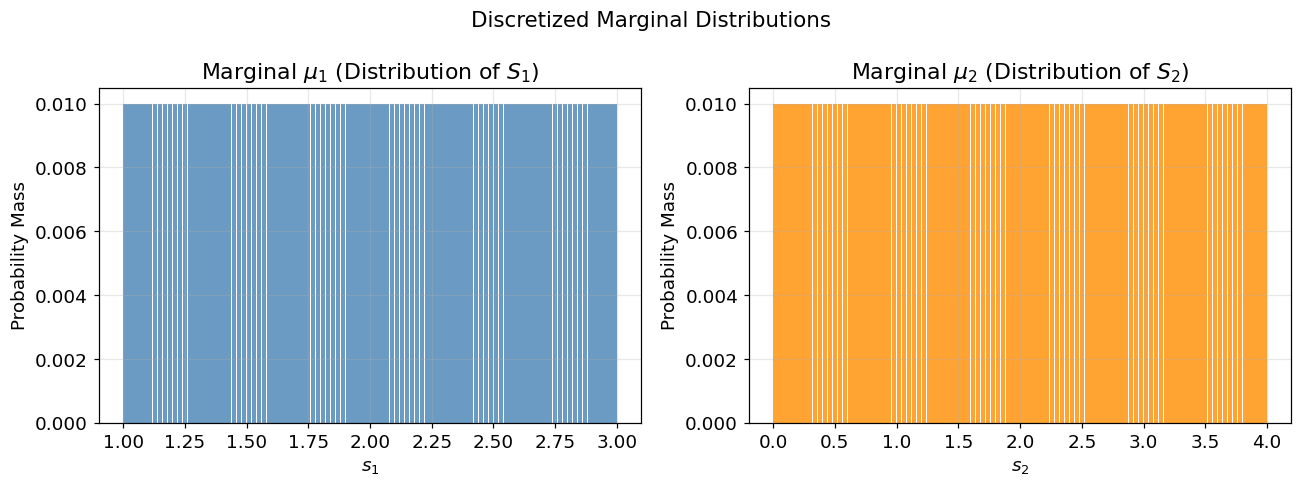

In [28]:

import scipy.stats as stats

def discretize_dist(dist, a, b, n):
    """
    Discretize a scipy.stats distribution on the interval [a, b] using n atoms.
    Atoms are placed at the midpoints of n equal-width sub-intervals.
    Weights are assigned based on the CDF difference to ensure exact bin masses.
    """
    edges = np.linspace(a, b, n + 1)
    atoms = 0.5 * (edges[:-1] + edges[1:])
    
    # Calculate probability mass for each bin using the CDF
    weights = dist.cdf(edges[1:]) - dist.cdf(edges[:-1])
    
    # Normalize weights so they sum exactly to 1 (handles truncated distributions)
    if weights.sum() > 0:
        weights /= weights.sum()
    else:
        weights = np.ones(n) / n # Fallback
        
    return atoms, weights

n = 100  # grid size — increase for higher accuracy
# dist_S1 = stats.truncnorm((0-2)/0.4, (4-2)/0.4, loc=2, scale=0.4)
# dist_S2 = stats.truncnorm((0-2)/1.0, (4-2)/1.0, loc=2, scale=1.0)
# x_atoms, alpha = discretize_dist(dist_S1, 0.1, 3.9, n)
# y_atoms, beta  = discretize_dist(dist_S2, 0.1, 3.9, n)


# k1, k2 = 8.0, 2.0           # k1 > k2 → S1 has smaller variance
# dist_S1 = stats.gamma(a=k1, scale=2/k1)   # mean=2, Var=4/k1=0.5
# dist_S2 = stats.gamma(a=k2, scale=2/k2)   # mean=2, Var=4/k2=2.0
# x_atoms, alpha = discretize_dist(dist_S1, 0.01, 6, n)
# y_atoms, beta  = discretize_dist(dist_S2, 0.01, 6, n)

dist_S1 = stats.uniform(loc=1, scale=2)
dist_S2 = stats.uniform(loc=0, scale=4)
x_atoms, alpha = discretize_dist(dist_S1, 1, 3, n)   

y_atoms, beta = discretize_dist(dist_S2, 0, 4, n)   

# --- Verification ---
E_S1 = (x_atoms * alpha).sum()
E_S2 = (y_atoms * beta).sum()
Var_S1 = (x_atoms**2 * alpha).sum() - E_S1**2
Var_S2 = (y_atoms**2 * beta).sum()  - E_S2**2

print(f"Grid size  n = {n}")
print(f"E[S1]   = {E_S1:.6f}")
print(f"E[S2]   = {E_S2:.6f}")
print(f"Var[S1] = {Var_S1:.6f}")
print(f"Var[S2] = {Var_S2:.6f}")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot for S1 (mu_1)
axes[0].bar(x_atoms, alpha, width=(x_atoms[1]-x_atoms[0])*0.9, color='steelblue', alpha=0.8)
axes[0].set_title('Marginal $\\mu_1$ (Distribution of $S_1$)')
axes[0].set_xlabel('$s_1$')
axes[0].set_ylabel('Probability Mass')
axes[0].grid(True, alpha=0.3)

# Plot for S2 (mu_2)
axes[1].bar(y_atoms, beta, width=(y_atoms[1]-y_atoms[0])*0.9, color='darkorange', alpha=0.8)
axes[1].set_title('Marginal $\\mu_2$ (Distribution of $S_2$)')
axes[1].set_xlabel('$s_2$')
axes[1].set_ylabel('Probability Mass')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Discretized Marginal Distributions', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Entropic Relaxation and Sinkhorn's Algorithm (Henry-Labordère §2.2)

### 3.1  The regularized primal

Following §2.2 of Henry-Labordère (2019), we penalize the primal by the **relative entropy** of $P$ with respect to a prior $P^0$:

$$\mathrm{MK}_c^\varepsilon(\mu^1,\mu^2) := \sup_{P\in\mathcal{M}(\mu^1,\mu^2)} \mathbb{E}^P[c(S_1,S_2)] - \varepsilon\, H(P|P^0)$$

where $H(P|P^0) = \mathbb{E}^P\!\bigl[\ln\frac{dP}{dP^0}-1\bigr]$ and $\varepsilon>0$ is taken small. Key points:

- The penalty is **minus** relative entropy: we subtract it, discouraging plans far from $P^0$.
- $\lim_{\varepsilon\to 0}\mathrm{MK}_c^\varepsilon = \mathrm{MK}_c$: exact MOT is recovered.
- We choose $P^0 = \mu^1\otimes\mu^2$, so $p^0_{ij} = \alpha_i\beta_j$.

### 3.2  The dual (Eq. 4 of the paper)

By Fenchel–Rockafellar duality:

$$\mathrm{MK}_c^\varepsilon = \inf_{u_1,u_2,h}\;\mathbb{E}^{\mu^1}[u_1] + \mathbb{E}^{\mu^2}[u_2] + \varepsilon\,\mathbb{E}^{P^0}\!\Bigl[e^{\frac{1}{\varepsilon}(c - u_1(S_1) - u_2(S_2) - h(S_1)(S_2-S_1))}\Bigr]$$

Once the optimal $(u_1^*,u_2^*,h^*)$ are found, the optimal plan is:

$$p^*_{ij} = \underbrace{\alpha_i\beta_j}_{p^0_{ij}}\cdot e^{\frac{1}{\varepsilon}\left(G_{ij}\,-\,u_1(s^i_1)\,-\,u_2(s^j_2)\,-\,h(s^i_1)(s^j_2-s^i_1)\right)}$$

### 3.3  First-order optimality conditions (Eqs. 5, 6, 7)

Setting each gradient to zero and discretizing:

**Eq. 5** — gradient w.r.t. $u_1(s^i_1)$, solved explicitly:
$$\boxed{u_1(s^i_1) = \varepsilon\ln\sum_j \beta_j\, e^{\frac{G_{ij} - u_2(s^j_2) - h(s^i_1)(s^j_2-s^i_1)}{\varepsilon}}}$$

**Eq. 6** — gradient w.r.t. $u_2(s^j_2)$, solved explicitly:
$$\boxed{u_2(s^j_2) = \varepsilon\ln\sum_i \alpha_i\, e^{\frac{G_{ij} - u_1(s^i_1) - h(s^i_1)(s^j_2-s^i_1)}{\varepsilon}}}$$

**Eq. 7** — gradient w.r.t. $h(s^i_1)$, a **scalar root-finding problem** per row $i$:
$$\boxed{\sum_j \beta_j\,(s^j_2 - s^i_1)\, e^{\frac{G_{ij} - u_2(s^j_2) - h(s^i_1)(s^j_2-s^i_1)}{\varepsilon}} = 0}$$

The left-hand side is strictly decreasing in $h(s^i_1)$ (its derivative is $-\varepsilon^{-1}\sum_j\beta_j(s^j_2-s^i_1)^2 e^{(\cdot)}\leq 0$), so the root is unique and `brentq` converges reliably.

### 3.4  The algorithm (Section 2.2.1 of the paper)

Starting from $u_1^{(0)}=u_2^{(0)}=h^{(0)}=0$, each iteration does:

| Step | Update | Using |
|------|--------|-------|
| 1 | $u_1^{(n)}$ via Eq. 5 | $u_2^{(n-1)},\,h^{(n-1)}$ |
| 2 | $h^{(n)}$ via Eq. 7 (root-find) | $u_2^{(n-1)}$ |
| 3 | $u_2^{(n)}$ via Eq. 6 | $u_1^{(n)},\,h^{(n)}$ |

All three updates are computed in **log-space** (`logsumexp`) to avoid overflow for small $\varepsilon$.

### Step 1 — Building blocks and payoff definition

In [29]:
import numpy as np
from scipy.optimize import brentq
from scipy.special import logsumexp

# Grids are already defined from Section 2; restate them here for clarity
n1 = len(x_atoms)   # number of S1 atoms
n2 = len(y_atoms) 
k = 1.5
G_mat = np.maximum((y_atoms[None, :] + x_atoms[:,None])/2-k,0)   # payoff 

# Displacement matrix  D[i,j] = s2_j - s1_i  (used in h-update and plan)
D_mat = y_atoms[None, :] - x_atoms[:, None]   # shape (n, n)

print(f'Grid: {n} atoms each.  G range: [{G_mat.min():.3f}, {G_mat.max():.3f}]')
print(f'D range: [{D_mat.min():.3f}, {D_mat.max():.3f}]')


Grid: 100 atoms each.  G range: [0.000, 1.985]
D range: [-2.970, 2.970]


### Step 2 — Update $u_1$ (Eq. 5)

$$u_1(s^i_1) = \varepsilon\,\mathrm{logsumexp}_j\!\left[\ln\beta_j + \frac{G_{ij} - u_2(s^j_2) - h(s^i_1)(s^j_2-s^i_1)}{\varepsilon}\right]$$

Because $\ln\beta_j = -\ln n$ for uniform weights, this is a log-sum-exp over each row of an exponent matrix.

In [30]:
def update_u1(G, D, u2, h, beta, eps):
    """
    Eq. 5:  u1[i] = eps * logsumexp_j( log(beta[j]) + (G[i,j] - u2[j] - h[i]*D[i,j]) / eps )

    Parameters
    ----------
    G   : (m1, m2)  payoff matrix
    D   : (m1, m2)  displacement matrix  D[i,j] = y[j] - x[i]
    u2  : (m2,)     current dual potential for S2 marginal
    h   : (m1,)     current martingale multiplier
    beta: (m2,)     weights of S2 atoms
    eps : float     regularization parameter
    """
    # Exponent matrix A[i,j] = (G[i,j] - u2[j] - h[i]*D[i,j]) / eps
    A = (G - u2[None, :] - h[:, None] * D) / eps   # (m1, m2)
    # logsumexp_j [ log(beta[j]) + A[i,j] ] for each i
    log_beta = np.log(beta)                          # (m2,)
    u1_new = eps * logsumexp(log_beta[None, :] + A, axis=1)  # (m1,)
    return u1_new

# Quick sanity check at zero initialisation
u1_test = update_u1(G_mat, D_mat, np.zeros(n2), np.zeros(n1), beta, eps=0.5)
#                                  ↑ u2 has n2 entries  ↑ h has n1 entries
print('u1 range at init:', u1_test.min(), 'to', u1_test.max())


u1 range at init: 0.3741038807378947 to 1.292576763138211


### Step 3 — Update $h$ (Eq. 7, root-finding)

For each row $i$, find $\theta = h(s^i_1)$ solving:
$$f_i(\theta) = \sum_j \beta_j\,(s^j_2-s^i_1)\,e^{\frac{G_{ij}-u_2(s^j_2)-\theta(s^j_2-s^i_1)}{\varepsilon}} = 0$$

We compute $f_i$ in log-space by splitting positive and negative displacements $D_{ij} = s^j_2 - s^i_1$:
$$f_i(\theta) = \sum_{D_{ij}>0} \beta_j D_{ij} e^{A_{ij}(\theta)} - \sum_{D_{ij}<0} \beta_j |D_{ij}| e^{A_{ij}(\theta)}$$

Each half can be evaluated stably with `logsumexp`, and the sign of $f_i$ changes exactly once.

In [31]:
def update_h(G, D, u2, beta, eps, x, y, bracket=(-80., 80.)):
    """
    Eq. 7: for each i, find h[i] such that
        sum_j  beta[j] * D[i,j] * exp((G[i,j] - u2[j] - h[i]*D[i,j]) / eps) = 0

    Uses brentq row-by-row.  Works in log-space to handle small eps.
    """
    m1 = len(x)
    h_new = np.zeros(m1)
    log_beta = np.log(beta)

    for i in range(m1):
        g_row = G[i]           # (m2,)
        d_row = D[i]           # (m2,)  = y - x[i]
        base  = (g_row - u2) / eps   # (m2,)  part of exponent independent of theta

        def f(theta):
            # Full exponent: base - theta * d_row / eps
            exp_vals = np.exp(base - theta * d_row / eps)   # (m2,)
            return (beta * d_row * exp_vals).sum()

        # Evaluate at bracket endpoints to confirm sign change
        fa, fb = f(bracket[0]), f(bracket[1])
        if fa * fb > 0:
            # No sign change: x[i] is already at a boundary or equal marginals
            # Fall back to h=0 (keeps prior)
            h_new[i] = 0.0
        else:
            h_new[i] = brentq(f, bracket[0], bracket[1], xtol=1e-10, maxiter=300)

    return h_new
h_test = update_h(G_mat, D_mat, np.zeros(n2), beta, eps=0.5, x=x_atoms, y=y_atoms)
print('h range at init:', h_test.min(), 'to', h_test.max())

h range at init: 0.057155297450309395 to 0.6031024365299095


### Step 4 — Update $u_2$ (Eq. 6)

$$u_2(s^j_2) = \varepsilon\,\mathrm{logsumexp}_i\!\left[\ln\alpha_i + \frac{G_{ij} - u_1(s^i_1) - h(s^i_1)(s^j_2-s^i_1)}{\varepsilon}\right]$$

Symmetric to the $u_1$ update, but summing over rows instead of columns.

In [32]:
def update_u2(G, D, u1, h, alpha, eps):
    """
    Eq. 6:  u2[j] = eps * logsumexp_i( log(alpha[i]) + (G[i,j] - u1[i] - h[i]*D[i,j]) / eps )
    """
    B = (G - u1[:, None] - h[:, None] * D) / eps   # (m1, m2)
    log_alpha = np.log(alpha)                        # (m1,)
    u2_new = eps * logsumexp(log_alpha[:, None] + B, axis=0)  # (m2,)
    return u2_new

# Quick test
u2_test = update_u2(G_mat, D_mat, np.zeros(n1), np.zeros(n1), alpha, eps=0.5)
print('u2 range at init:', u2_test.min(), 'to', u2_test.max())

u2 range at init: 5.024831044320166e-05 to 1.570711347480042


### Step 5 — Reconstruct the plan and verify constraints

Given $(u_1, u_2, h)$, the optimal plan is:
$$p^*_{ij} = \alpha_i\beta_j \cdot e^{\frac{G_{ij} - u_1(s^i_1) - u_2(s^j_2) - h(s^i_1)(s^j_2-s^i_1)}{\varepsilon}}$$

Again computed in log-space to avoid overflow.

In [33]:
def reconstruct_plan(G, D, u1, u2, h, alpha, beta, eps):
    """
    p*[i,j] = alpha[i]*beta[j]*exp((G[i,j] - u1[i] - u2[j] - h[i]*D[i,j]) / eps)
    Computed in log-space: log_p[i,j] = log(alpha[i]) + log(beta[j]) + exponent
    """
    log_p = (np.log(alpha[:, None]) + np.log(beta[None, :])
             + (G - u1[:, None] - u2[None, :] - h[:, None] * D) / eps)
    P = np.exp(log_p)
    return P

def constraint_errors(P, alpha, beta, x, y):
    """Return max absolute errors for the three constraint groups."""
    e1 = np.max(np.abs(P.sum(axis=1) - alpha))             # S1 marginal
    e2 = np.max(np.abs(P.sum(axis=0) - beta))              # S2 marginal
    cond_mean = (P * y[None, :]).sum(axis=1)               # E[S2 | S1=x_i] * alpha_i
    e3 = np.max(np.abs(cond_mean - alpha * x))             # martingale
    return e1, e2, e3


### Step 6 — Full Sinkhorn loop

We now put all four steps together, exactly as described in Section 2.2.1 of the paper.
The loop tracks the three constraint errors so we can monitor convergence.

In [34]:
def sinkhorn_HL(x, alpha, y, beta, G, eps, n_iter=1000, tol=1e-7, verbose=True):
    """
    Sinkhorn algorithm from Henry-Labordere (2019) Section 2.2.1.

    Minimises the dual:
        E^mu1[u1] + E^mu2[u2] + eps * E^P0[ exp((G - u1 - u2 - h*(S2-S1))/eps) ]

    Iteration order (paper steps 2-3-4):
        1. Update u1 via Eq. 5
        2. Update h  via Eq. 7 (root-finding, uses old u2)
        3. Update u2 via Eq. 6

    Returns
    -------
    P      : (m1, m2) optimal transport plan
    value  : float    primal objective E[G] (without entropy term)
    history: dict     convergence trace
    u1, u2, h : arrays of final dual potentials
    """
    D = y[None, :] - x[:, None]     # displacement matrix

    # Initialise all potentials to zero (paper step 1)
    u1 = np.zeros(len(x))
    u2 = np.zeros(len(y))
    h  = np.zeros(len(x))

    history = {'err_u1': [], 'err_u2': [], 'err_mart': [], 'value': []}

    for it in range(n_iter):
        # ── Paper step 2: update u1 (Eq. 5) ──────────────────────────────
        u1 = update_u1(G, D, u2, h, beta, eps)

        # ── Paper step 3: update h (Eq. 7, using OLD u2) ─────────────────
        h  = update_h(G, D, u2, beta, eps, x, y)

        # ── Paper step 4: update u2 (Eq. 6) ──────────────────────────────
        u2 = update_u2(G, D, u1, h, alpha, eps)

        # ── Reconstruct plan and check convergence ────────────────────────
        P = reconstruct_plan(G, D, u1, u2, h, alpha, beta, eps)
        e1, e2, e3 = constraint_errors(P, alpha, beta, x, y)
        val = (P * G).sum()

        history['err_u1'].append(e1)
        history['err_u2'].append(e2)
        history['err_mart'].append(e3)
        history['value'].append(val)

        if max(e1, e2, e3) < tol:
            if verbose:
                print(f'  Converged at iteration {it+1}')
                print(f'  S1 marginal error : {e1:.2e}')
                print(f'  S2 marginal error : {e2:.2e}')
                print(f'  Martingale error  : {e3:.2e}')
            break
    else:
        if verbose:
            print(f'  Did not converge in {n_iter} iterations')
            print(f'  Final — S1: {e1:.2e}, S2: {e2:.2e}, martingale: {e3:.2e}')

    return P, val, history, u1, u2, h


# ── Run it ────────────────────────────────────────────────────────────────────
eps = 0.005
P_sink, val_sink, hist, u1_opt, u2_opt, h_opt = sinkhorn_HL(
    x_atoms, alpha, y_atoms, beta, G_mat, eps=eps
)
print(f'\n  Sinkhorn E[G(S1-S2)]  (eps={eps}) : {val_sink:.6f}')


C:\Users\123\AppData\Local\Temp\ipykernel_29532\1508501900.py:19: RuntimeWarning: overflow encountered in exp
  exp_vals = np.exp(base - theta * d_row / eps)   # (m2,)


  Converged at iteration 166
  S1 marginal error : 5.75e-08
  S2 marginal error : 2.64e-16
  Martingale error  : 9.72e-08

  Sinkhorn E[G(S1-S2)]  (eps=0.005) : 0.657165


## 3.4. Verify the dual potentials

The dual objective evaluated at $(u_1^*, u_2^*, h^*)$ should equal (or upper-bound) the primal value.
We also check that the plan $p^*_{ij}$ satisfies all three constraints to near machine precision.

In [35]:
# Dual objective value (Eq. 4)
exp_term = np.exp(
    (G_mat - u1_opt[:, None] - u2_opt[None, :] - h_opt[:, None] * D_mat) / eps
)
# P0 = alpha_i * beta_j, so E^P0[...] = sum_ij alpha_i beta_j exp(...)
dual_obj = ((alpha * u1_opt).sum()
            + (beta  * u2_opt).sum()
            + eps * (alpha[:, None] * beta[None, :] * exp_term).sum())

print('━━ Dual verification ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Dual objective (Eq.4)     : {dual_obj:.6f}')
print(f'  Primal E[G] from plan     : {val_sink:.6f}')
print(f'  Gap (dual - primal)       : {dual_obj - val_sink:.2e}  (should be >= 0)')
print()
e1, e2, e3 = constraint_errors(P_sink, alpha, beta, x_atoms, y_atoms)
print('━━ Plan constraint errors ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  S1 marginal  : {e1:.2e}')
print(f'  S2 marginal  : {e2:.2e}')
print(f'  Martingale   : {e3:.2e}')
print(f'  All p_ij>=0  : {(P_sink >= -1e-12).all()}')


━━ Dual verification ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dual objective (Eq.4)     : 0.658043
  Primal E[G] from plan     : 0.657165
  Gap (dual - primal)       : 8.78e-04  (should be >= 0)

━━ Plan constraint errors ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  S1 marginal  : 5.75e-08
  S2 marginal  : 2.64e-16
  Martingale   : 9.72e-08
  All p_ij>=0  : True


### 3.5. Convergence history 

C:\Users\123\AppData\Local\Temp\ipykernel_29532\3910557929.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


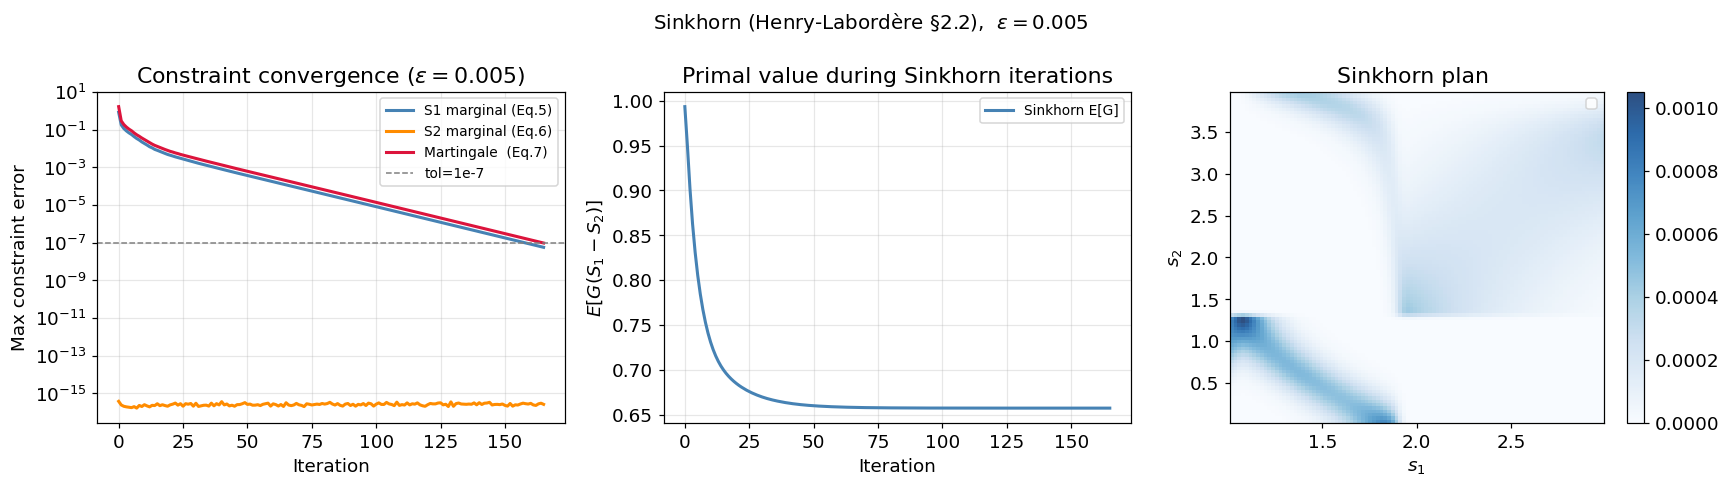

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (A) Constraint errors per iteration
ax = axes[0]
ax.semilogy(hist['err_u1'],   lw=2, color='steelblue',  label='S1 marginal (Eq.5)')
ax.semilogy(hist['err_u2'],   lw=2, color='darkorange', label='S2 marginal (Eq.6)')
ax.semilogy(hist['err_mart'], lw=2, color='crimson',    label='Martingale  (Eq.7)')
ax.axhline(1e-7, color='grey', ls='--', lw=1, label='tol=1e-7')
ax.set_xlabel('Iteration'); ax.set_ylabel('Max constraint error')
ax.set_title(f'Constraint convergence ($\\varepsilon={eps}$)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (B) Primal value per iteration vs LP
ax = axes[1]
ax.plot(hist['value'], lw=2, color='steelblue', label=f'Sinkhorn E[G]')
ax.set_xlabel('Iteration'); ax.set_ylabel('$E[G(S_1-S_2)]$')
ax.set_title('Primal value during Sinkhorn iterations')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (C) Side-by-side plans
ax = axes[2]
im = ax.imshow(P_sink.T, origin='lower', aspect='auto',
               extent=[x_atoms[0],x_atoms[-1],y_atoms[0],y_atoms[-1]],
               cmap='Blues', interpolation='nearest', alpha=0.85)
ax.set_xlabel('$s_1$'); ax.set_ylabel('$s_2$')
ax.set_title(f' Sinkhorn plan  ')
ax.legend(fontsize=9)
plt.colorbar(im, ax=ax)

plt.suptitle(f'Sinkhorn (Henry-Labordère §2.2),  $\\varepsilon={eps}$', fontsize=13)
plt.tight_layout()
plt.show()


### 3.6. Regularization path: $\varepsilon \to 0$

As the paper notes, $\mathrm{MK}_c^\varepsilon \to \mathrm{MK}_c$ as $\varepsilon\to 0$, but the algorithm becomes numerically unstable for very small $\varepsilon$ — the exponentials overflow/underflow. This is explicitly flagged in Section 2.2 and §4 of the paper as a known limitation of entropic relaxation.

We demonstrate both the convergence and the instability threshold.

     eps    E[|S1-S2|]      status
  --------------------------------
   2.000      0.627546          ok
   1.000      0.628441          ok
   0.500      0.630174          ok


C:\Users\123\AppData\Local\Temp\ipykernel_29532\1508501900.py:19: RuntimeWarning: overflow encountered in exp
  exp_vals = np.exp(base - theta * d_row / eps)   # (m2,)
C:\Users\123\AppData\Local\Temp\ipykernel_29532\1508501900.py:24: RuntimeWarning: overflow encountered in scalar multiply
  if fa * fb > 0:


   0.300      0.632354          ok
   0.150      0.637068          ok
   0.080      0.642935          ok
   0.010      0.655960          ok
  --------------------------------


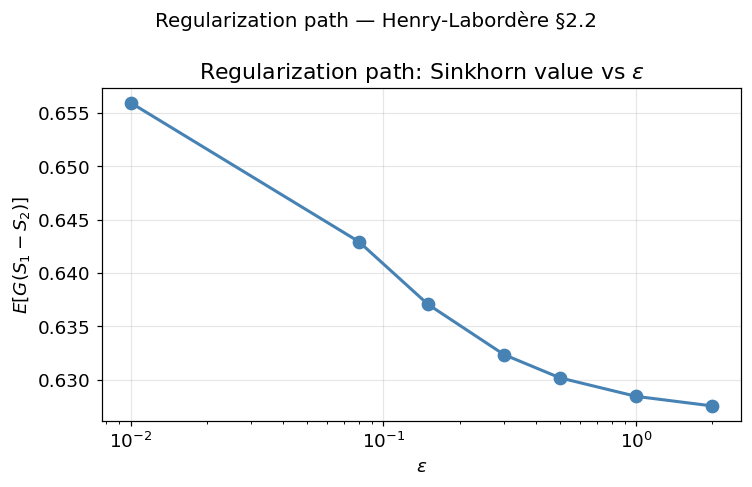

In [37]:
eps_list = [2.0, 1.0, 0.5, 0.3, 0.15, 0.08, 0.01]
sink_vals = []
sink_ok   = []

print(f'  {"eps":>6}  {"E[|S1-S2|]":>12}  {"status":>10}')
print('  ' + '-'*32)

for eps_i in eps_list:
    try:
        _, v_i, _, _, _, _ = sinkhorn_HL(
            x_atoms, alpha, y_atoms, beta, G_mat,
            eps=eps_i, n_iter=600, tol=1e-8, verbose=False
        )
        ok = np.isfinite(v_i) and v_i > 0
        sink_vals.append(v_i if ok else np.nan)
        sink_ok.append(ok)
        status = 'ok' if ok else 'UNSTABLE'
        print(f'  {eps_i:>6.3f}  {v_i:>12.6f}  {status:>10}')
    except Exception as e:
        sink_vals.append(np.nan)
        sink_ok.append(False)
        print(f'  {eps_i:>6.3f}  {"NaN":>12}  FAILED')

print('  ' + '-'*32)

# Plot
valid = [(e, v) for e, v, ok in zip(eps_list, sink_vals, sink_ok) if ok and np.isfinite(v)]
if valid:
    eps_v, vals_v = zip(*valid)
    fig, ax = plt.subplots(figsize=(7, 4.5))

    ax.semilogx(eps_v, vals_v, 'o-', color='steelblue', lw=2, ms=8)
    ax.set_xlabel('$\\varepsilon$') 
    ax.set_ylabel('$E[G(S_1-S_2)]$')
    ax.set_title('Regularization path: Sinkhorn value vs $\\varepsilon$')
    ax.grid(True, alpha=0.3)

    plt.suptitle('Regularization path — Henry-Labordère §2.2', fontsize=13)
    plt.tight_layout()
    plt.show()
  


### 3.7. Transport plans across $\varepsilon$ values

As $\varepsilon\to 0$ the smooth Sinkhorn plan concentrates toward the sparse LP solution.

C:\Users\123\AppData\Local\Temp\ipykernel_29532\1508501900.py:19: RuntimeWarning: overflow encountered in exp
  exp_vals = np.exp(base - theta * d_row / eps)   # (m2,)
C:\Users\123\AppData\Local\Temp\ipykernel_29532\1508501900.py:24: RuntimeWarning: overflow encountered in scalar multiply
  if fa * fb > 0:


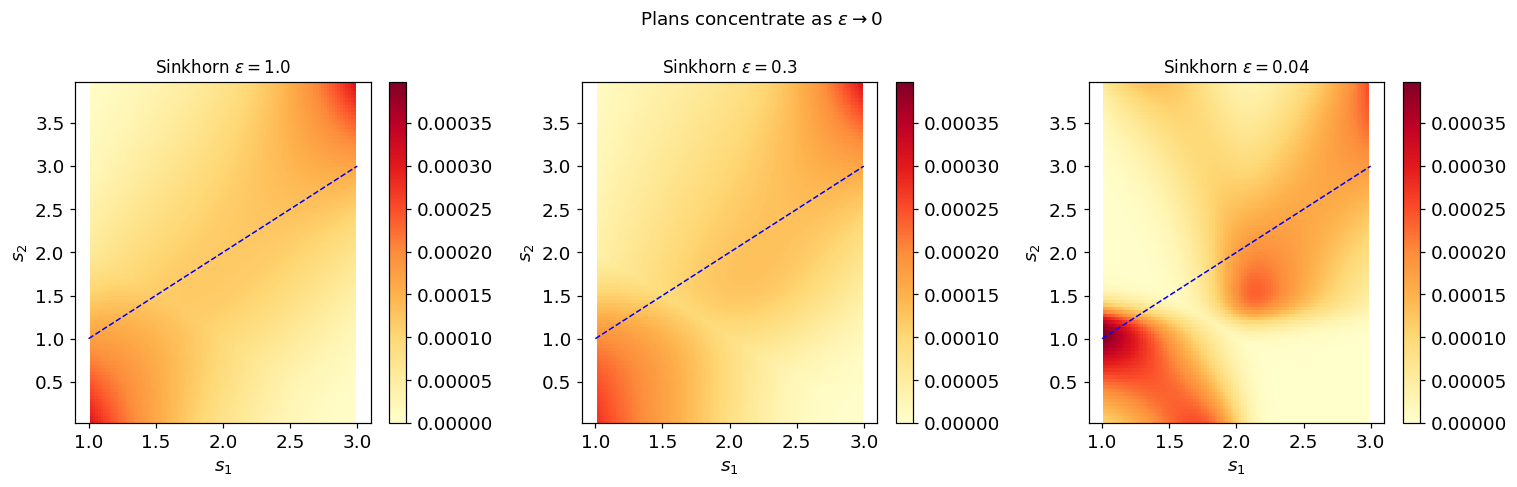

In [38]:
eps_show = [1.0, 0.3, 0.04]
plans_s = []
for eps_i in eps_show:
    P_i, _, _, _, _, _ = sinkhorn_HL(
        x_atoms, alpha, y_atoms, beta, G_mat,
        eps=eps_i, n_iter=600, tol=1e-8, verbose=False
    )
    plans_s.append(P_i)

titles_s = [f'Sinkhorn $\\varepsilon={e}$' for e in eps_show] 

# Changed from 4 subplots to 3, adjusted figure size
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
vmax = max(P.max() for P in plans_s)

for ax, P_i, title in zip(axes, plans_s, titles_s):
    im = ax.imshow(P_i.T, origin='lower', aspect='auto',
                   extent=[x_atoms[0],x_atoms[-1],y_atoms[0],y_atoms[-1]],
                   cmap='YlOrRd', interpolation='nearest', vmin=0, vmax=vmax)
    ax.plot([1,3],[1,3],'b--',lw=1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$s_1$'); ax.set_ylabel('$s_2$')
    plt.colorbar(im, ax=ax)

# Updated title to remove the LP reference
plt.suptitle(
    'Plans concentrate as $\\varepsilon\\to 0$',
    fontsize=12
)
plt.tight_layout()
plt.show()
